In [27]:
from optparse import Values

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [3]:
df_customers = pd.read_csv("DataSet/customers.csv")
df_customers.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [4]:
df_cs = pd.read_csv("DataSet/credit_profiles.csv")
df_trans = pd.read_csv("DataSet/transactions.csv")

In [5]:
df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [6]:
df_trans.shape

(500000, 7)

Handling Null Values (Annual Income)

In [7]:
df_customers.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


In [8]:
df_customers.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [9]:
df_customers.annual_income.isna()

0      False
1      False
2      False
3      False
4      False
       ...  
995     True
996    False
997    False
998     True
999    False
Name: annual_income, Length: 1000, dtype: bool

In [10]:
df_customers[df_customers.annual_income.isna()].head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,NaN,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,NaN,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,NaN,Married
102,103,Pooja Ganguly,Male,32,City,Data Scientist,NaN,Married
155,156,Krishna Trivedi,Male,24,City,Fullstack Developer,NaN,Married


In [11]:
df_customers.annual_income.median()

np.float64(112218.5)

In [12]:
df_customers[df_customers.occupation == "Artist"].annual_income.median()

np.float64(45794.0)

In [13]:
df_customers[df_customers.occupation == "Freelancer"].annual_income.median()

np.float64(46759.0)

In [14]:
df_customers[df_customers.occupation == "Data Scientist"].annual_income.median()

np.float64(135759.0)

In [17]:
occupation_wise_median  =df_customers.groupby("occupation").annual_income.median()
occupation_wise_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [18]:
occupation_wise_median["Artist"]

np.float64(45794.0)

In [21]:
def get_median_val(row):
    if pd.isnull(row["annual_income"]):
        return occupation_wise_median(row["occupation"])
    else:
        return row["annual_income"]

get_median_val({"cust_id" : 3245 ,"occupation" : "Artist" ,"annual_income": 678})

678

In [22]:
df_customers["annual_income"] = df_customers.apply(
    lambda row: occupation_wise_median[row["occupation"]] if pd.isnull(row["annual_income"]) else row["annual_income"] ,
    axis =1)

In [23]:
df_customers.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [24]:
df_customers.iloc[[14,82]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,46759.0,Single


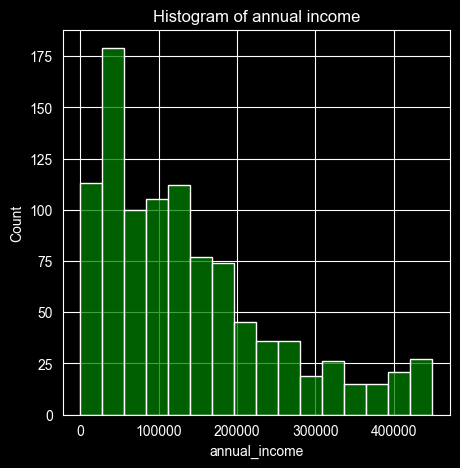

In [29]:
plt.figure(figsize=(5,5))
sns.histplot(df_customers["annual_income"],kde = False,color="green",label = 'Data')
plt.title("Histogram of annual income")
plt.show()

DATA CLEANING